# Climate model emulation: a hands-on tutorial

This tutorial accompanies the [Climate Model Emulation](emulation.md) notes. There we
distinguished **parameter emulation** (the subject of the [ANN tutorial](../DeepLearning/ann_tutorial.ipynb) in Week 9) from **scenario emulation**.
This notebook builds the second kind.

The task: given global annual forcing time series (cumulative CO$_2$, methane, and aerosol
emissions), predict the **spatial field** of surface temperature anomaly that a general
circulation model would have produced. We train on five scenarios and test on a sixth the
emulator never sees.

We use **ClimateBench** (Watson-Parris et al. 2022), the standard public benchmark for this
problem, built from NorESM2 simulations.

```{admonition} What to watch for
:class: tip
The headline result of this notebook is that the *simplest* model wins by a wide margin, and
the reason is specific and worth understanding. Do not skip Part 5.
```

In [1]:
import os
import tarfile
import urllib.request

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Downloading the data

ClimateBench is on Zenodo under CC-BY-4.0. The two archives together are about 900 MB, so
this takes a few minutes the first time and is cached afterwards.

In [2]:
DATA = "climatebench_data"
ZENODO = "https://zenodo.org/api/records/7064308/files"

os.makedirs(DATA, exist_ok=True)
for name in ["train_val.tar.gz", "test.tar.gz"]:
    path = os.path.join(DATA, name)
    if not os.path.exists(path) and not os.path.exists(os.path.join(DATA, "inputs_ssp245.nc")):
        print(f"downloading {name} ...")
        urllib.request.urlretrieve(f"{ZENODO}/{name}/content", path)
    if os.path.exists(path):
        with tarfile.open(path) as t:
            t.extractall(DATA)
        os.remove(path)

print(sorted(f for f in os.listdir(DATA) if f.endswith(".nc"))[:6], "...")

['inputs_1pctCO2.nc', 'inputs_abrupt-4xCO2.nc', 'inputs_hist-GHG.nc', 'inputs_hist-aer.nc', 'inputs_historical.nc', 'inputs_ssp126.nc'] ...


## Part 1: What is in the data

Each scenario comes as an `inputs_*.nc` and an `outputs_*.nc` file. The inputs are the
forcings, the outputs are what NorESM2 produced.

In [3]:
inp = xr.open_dataset(f"{DATA}/inputs_ssp245.nc")
out = xr.open_dataset(f"{DATA}/outputs_ssp245.nc")

print("INPUTS")
for v in inp.data_vars:
    print(f"  {v:<5} dims={inp[v].dims}  shape={inp[v].shape}")
print("\nOUTPUTS")
for v in out.data_vars:
    print(f"  {v:<26} dims={out[v].dims}  shape={out[v].shape}")

INPUTS
  CO2   dims=('time',)  shape=(86,)
  SO2   dims=('time', 'latitude', 'longitude')  shape=(86, 96, 144)
  CH4   dims=('time',)  shape=(86,)
  BC    dims=('time', 'latitude', 'longitude')  shape=(86, 96, 144)

OUTPUTS
  diurnal_temperature_range  dims=('member', 'time', 'lat', 'lon')  shape=(3, 86, 96, 144)
  tas                        dims=('member', 'time', 'lat', 'lon')  shape=(3, 86, 96, 144)
  pr                         dims=('member', 'time', 'lat', 'lon')  shape=(3, 86, 96, 144)
  pr90                       dims=('member', 'time', 'lat', 'lon')  shape=(3, 86, 96, 144)


Two things to notice.

**CO$_2$ and CH$_4$ are global scalars** (one number per year) while **SO$_2$ and BC are
spatial fields**. That asymmetry is physical: greenhouse gases are long-lived and well mixed
through the atmosphere, so their concentration is effectively uniform. Aerosols have
lifetimes of days to weeks, so they stay near their sources and their forcing is regional.

**The outputs have a `member` dimension.** NorESM2 was run three times per scenario with
different initial conditions. The spread between members is *internal variability*, the
climate system's own chaos, not a response to forcing. No emulator can predict it, because
the forcings that drive the emulator are identical across the three runs.

Averaging the members suppresses it by a factor of $\sqrt{3}$, and that reduced number is
the **aleatoric floor** for this task: the best possible field RMSE, achieved by an emulator
that has perfectly learned the forced response. Keep it in mind when reading the scores in
Part 4; it tells you how much of the remaining error is even reducible.

mean spread across the 3 ensemble members: 0.450 K
we predict the 3-member MEAN, whose noise is smaller by sqrt(3): 0.260 K
That is the aleatoric floor for this task -- no emulator can do better.


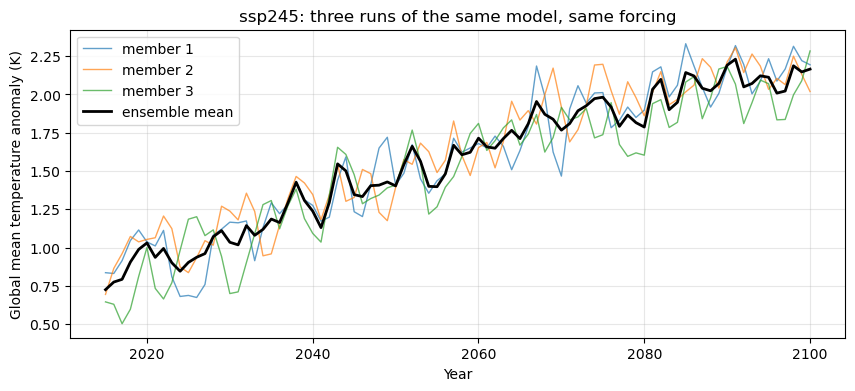

In [4]:
tas = out["tas"]
member_spread = tas.std("member").mean().item()
print(f"mean spread across the 3 ensemble members: {member_spread:.3f} K")
print(f"we predict the 3-member MEAN, whose noise is smaller by sqrt(3): "
      f"{member_spread / np.sqrt(3):.3f} K")
print("That is the aleatoric floor for this task -- no emulator can do better.")

fig, ax = plt.subplots(figsize=(10, 4))
w = np.cos(np.deg2rad(tas.lat))
for m in range(tas.sizes["member"]):
    gm = tas.isel(member=m).weighted(w).mean(("lat", "lon"))
    ax.plot(tas.time, gm, lw=1, alpha=0.7, label=f"member {m+1}")
ax.plot(tas.time, tas.mean("member").weighted(w).mean(("lat", "lon")),
        lw=2, color="k", label="ensemble mean")
ax.set_xlabel("Year"); ax.set_ylabel("Global mean temperature anomaly (K)")
ax.set_title("ssp245: three runs of the same model, same forcing")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## Part 2: Build the training set

We train on five scenarios and hold out `ssp245` entirely. This is the ClimateBench design,
and it is a much harder test than a random split over years: the emulator must generalise to
a forcing pathway it has never seen, not merely to years it has not seen.

In [5]:
TRAIN = ["historical", "ssp126", "ssp370", "ssp585", "hist-GHG", "hist-aer"]
TEST = "ssp245"

def load(scenario):
    i = xr.open_dataset(f"{DATA}/inputs_{scenario}.nc")
    o = xr.open_dataset(f"{DATA}/outputs_{scenario}.nc")
    field = o["tas"].mean("member")                 # average out internal variability
    X = np.column_stack([
        i["CO2"].values,
        i["CH4"].values,
        i["SO2"].mean(("latitude", "longitude")).values,   # global mean aerosol
        i["BC"].mean(("latitude", "longitude")).values,
    ])
    Y = field.values.reshape(field.shape[0], -1)    # (time, lat*lon)
    return X, Y, field

Xtr, Ytr = [], []
for s in TRAIN:
    x, y, _ = load(s)
    Xtr.append(x); Ytr.append(y)
    print(f"  {s:<12} {x.shape[0]:>4} years")
Xtr, Ytr = np.vstack(Xtr), np.vstack(Ytr)
Xte, Yte, field_te = load(TEST)

FEATURES = ["CO2", "CH4", "SO2", "BC"]
print(f"\ntrain: X{Xtr.shape} -> Y{Ytr.shape}")
print(f"test:  X{Xte.shape} -> Y{Yte.shape}   (held-out scenario: {TEST})")
print(f"predicting {Ytr.shape[1]:,} grid cells from {Xtr.shape[1]} numbers")

  historical    165 years
  ssp126         86 years
  ssp370         86 years
  ssp585         86 years
  hist-GHG      165 years


  hist-aer      165 years



train: X(753, 4) -> Y(753, 13824)
test:  X(86, 4) -> Y(86, 13824)   (held-out scenario: ssp245)
predicting 13,824 grid cells from 4 numbers


## Part 3: Scoring

Grid cells do not represent equal areas (a cell at 80°N covers far less surface than one at the equator) so we area-weight the error, exactly as in the PCA assignment. We report two
numbers: the area-weighted RMSE over the whole field, and the RMSE of the global mean series.

In [6]:
lat = field_te.lat.values
weights = np.repeat(np.cos(np.deg2rad(lat)), field_te.sizes["lon"])
weights = weights / weights.sum()

def evaluate(name, pred, store={}):
    rmse = np.sqrt((weights * (pred - Yte) ** 2).sum(axis=1).mean())
    gm_pred, gm_true = (pred * weights).sum(1), (Yte * weights).sum(1)
    gm_rmse = np.sqrt(((gm_pred - gm_true) ** 2).mean())
    print(f"{name:<32} field RMSE = {rmse:.4f} K    global-mean RMSE = {gm_rmse:.4f} K")
    store[name] = (pred, rmse, gm_rmse)
    return store

results = evaluate("baseline: mean training field",
                   np.tile(Ytr.mean(0), (len(Yte), 1)))

baseline: mean training field    field RMSE = 1.1988 K    global-mean RMSE = 0.9941 K


## Part 4: Three emulators

**Pattern scaling** is the classical climate-science emulator: assume the spatial response is
a fixed pattern whose amplitude scales linearly with forcing. In machine learning terms that
is simply a multi-output linear regression.

In [7]:
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

linear = LinearRegression().fit(Xtr_s, Ytr)
results = evaluate("linear (pattern scaling)", linear.predict(Xte_s))

rf = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1).fit(Xtr_s, Ytr)
results = evaluate("random forest (direct)", rf.predict(Xte_s))

# Reduce, then emulate: compress the field to a few EOFs, emulate those, project back.
pca = PCA(n_components=10).fit(Ytr)
rf_pca = RandomForestRegressor(n_estimators=200, random_state=0,
                               n_jobs=-1).fit(Xtr_s, pca.transform(Ytr))
results = evaluate("PCA(10) + random forest", pca.inverse_transform(rf_pca.predict(Xte_s)))

print(f"\n10 EOFs retain {100 * pca.explained_variance_ratio_.sum():.1f}% of the field variance")
print(f"  -- {Ytr.shape[1]:,} grid cells compressed to 10 numbers")

linear (pattern scaling)         field RMSE = 0.3739 K    global-mean RMSE = 0.1107 K


random forest (direct)           field RMSE = 0.5519 K    global-mean RMSE = 0.3577 K


PCA(10) + random forest          field RMSE = 0.5351 K    global-mean RMSE = 0.3398 K

10 EOFs retain 94.6% of the field variance
  -- 13,824 grid cells compressed to 10 numbers


## Part 5: The result, and why

The linear emulator wins, and not narrowly. Before explaining it, look at where the error
actually is.

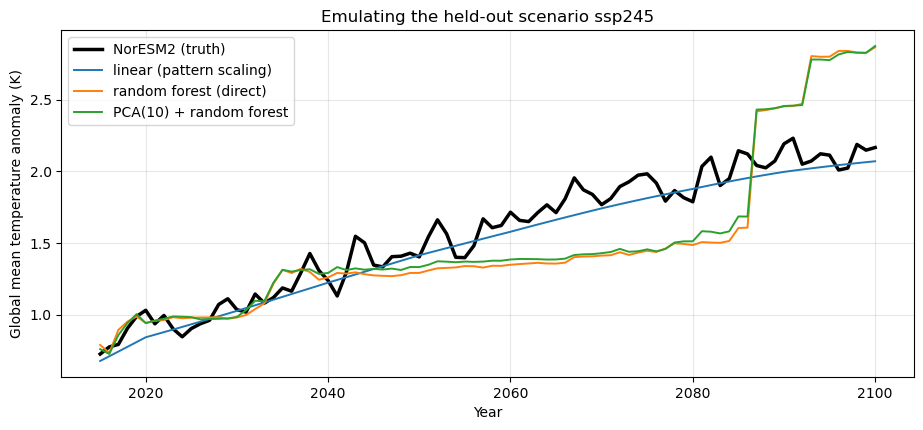

global mean anomaly in 2100 (K):
  truth                     2.17
  linear (pattern scaling)  2.07
  random forest (direct)    2.87


In [8]:
gm_true = (Yte * weights).sum(1)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(field_te.time, gm_true, "k", lw=2.5, label="NorESM2 (truth)")
for name in ["linear (pattern scaling)", "random forest (direct)", "PCA(10) + random forest"]:
    ax.plot(field_te.time, (results[name][0] * weights).sum(1), lw=1.4, label=name)
ax.set_xlabel("Year"); ax.set_ylabel("Global mean temperature anomaly (K)")
ax.set_title(f"Emulating the held-out scenario {TEST}")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print("global mean anomaly in 2100 (K):")
print(f"  truth                     {gm_true[-1]:.2f}")
for name in ["linear (pattern scaling)", "random forest (direct)"]:
    print(f"  {name:<25} {(results[name][0] * weights).sum(1)[-1]:.2f}")

The random forest **over-predicts late-century warming by roughly 0.7 K**: a third of the
signal. That is not a tuning problem, and more trees will not fix it. It is structural, and
the reason is worth working through carefully because it generalises well beyond this dataset.

A tree makes predictions by **averaging the training points that fall in the same leaf**. It
cannot produce a value outside the range of its training targets, and within that range it
can only produce weighted averages of what it has already seen.

Now look at where the training data actually sits in forcing space.

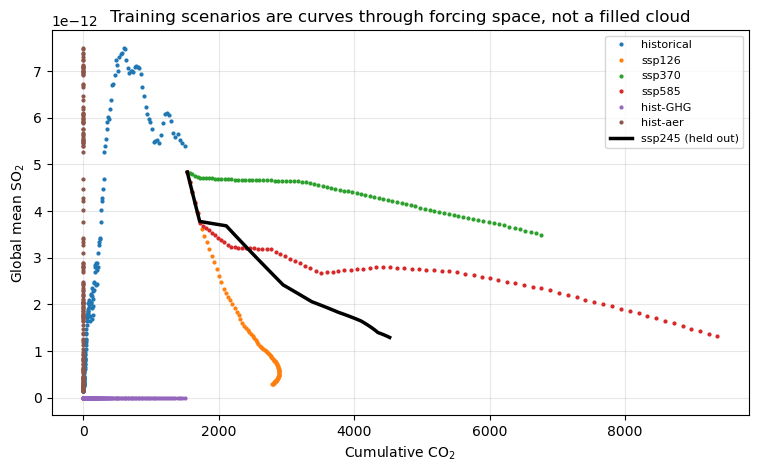

test rows inside the training range on every feature: 86/86


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
start = 0
for s in TRAIN:
    x, _, _ = load(s)
    ax.plot(x[:, 0], x[:, 2], ".", ms=4, label=s)
ax.plot(Xte[:, 0], Xte[:, 2], "k-", lw=2.5, label=f"{TEST} (held out)")
ax.set_xlabel("Cumulative CO$_2$"); ax.set_ylabel("Global mean SO$_2$")
ax.set_title("Training scenarios are curves through forcing space, not a filled cloud")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

inside = np.all((Xte >= Xtr.min(0)) & (Xte <= Xtr.max(0)), axis=1)
print(f"test rows inside the training range on every feature: {inside.sum()}/{len(Xte)}")

Every test point lies **inside** the training range, so this is not extrapolation in the
usual sense. The problem is subtler.

The training scenarios trace out a handful of one-dimensional **curves** through a
four-dimensional forcing space; they do not fill it. The held-out scenario is a *different*
curve, threading between them. To emulate it, a model has to interpolate *across* the gaps
between curves.

Linear regression does that gracefully: it fits a smooth function of the forcings and
evaluates it anywhere. The random forest has no such function. For a given ssp245 year, its
nearest training neighbours in forcing space come mostly from ssp370 and ssp585, scenarios
that reach comparable cumulative CO$_2$ but with **more aerosol cooling already scrubbed out
and higher methane**, and hence more warming. The forest averages those neighbours and
inherits their warmth.

Two lessons, and the second is the one that matters:

1. **Tree ensembles interpolate by local averaging.** When training data lies on sparse
   manifolds rather than filling the input space (which is exactly what a scenario ensemble looks like) that averaging is biased toward whichever training runs happen to be nearby.
2. **The physics here really is close to linear.** The temperature response to forcing is,
   to first order, a fixed spatial pattern scaled by global forcing. Pattern scaling has been
   the workhorse of climate emulation for thirty years for this reason. A model whose
   inductive bias matches the physics beats a more flexible model that has to discover the
   relationship from 753 samples.

This is the same lesson as Assignment 8, where a neural network barely beat linear regression
on streamflow, and Assignment 3, where an RBF kernel bought almost nothing over a linear
boundary. **Fit the simple model first.** It is not a formality, sometimes it wins.

## Part 6: Looking at the fields

A global mean hides spatial structure. Where is the emulator actually wrong?

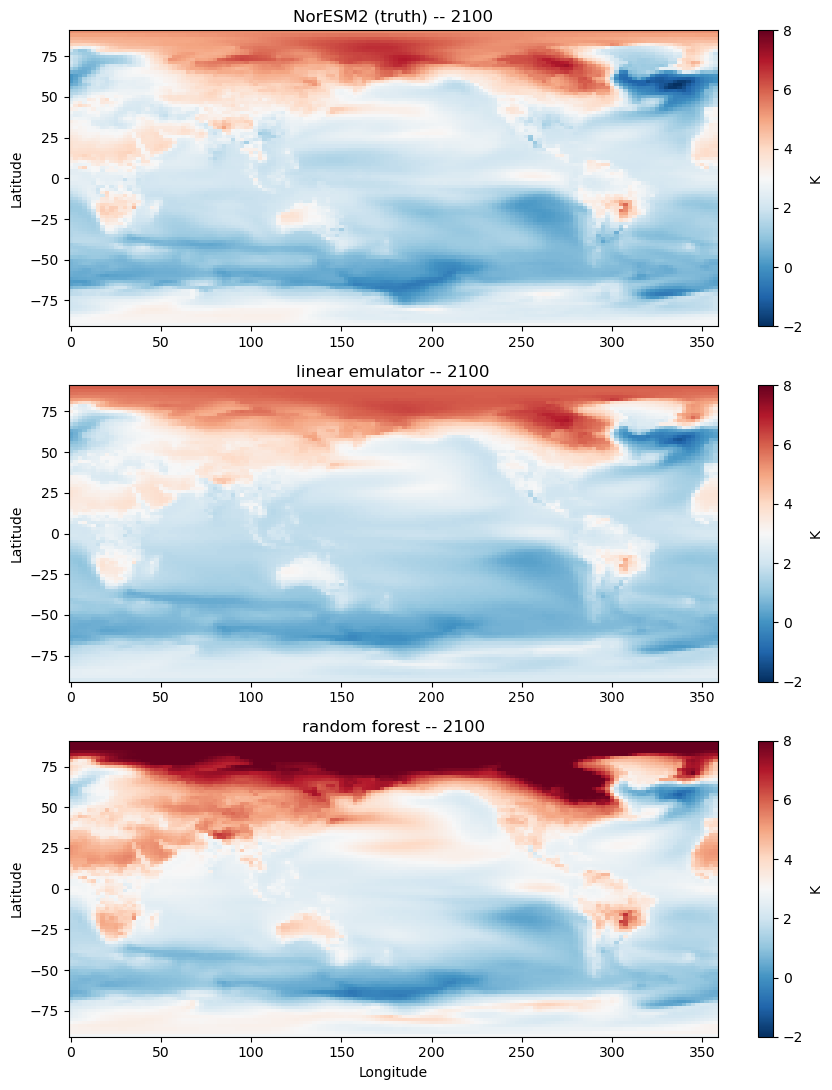

linear emulator      area-weighted RMSE in 2100: 0.324 K
random forest        area-weighted RMSE in 2100: 0.920 K


In [10]:
def to_map(vec):
    return vec.reshape(field_te.sizes["lat"], field_te.sizes["lon"])

year = -1                                        # 2100
truth = to_map(Yte[year])
panels = [("NorESM2 (truth)", truth),
          ("linear emulator", to_map(results["linear (pattern scaling)"][0][year])),
          ("random forest", to_map(results["random forest (direct)"][0][year]))]

fig, axes = plt.subplots(3, 1, figsize=(9, 11))
for ax, (label, fieldmap) in zip(axes, panels):
    m = ax.pcolormesh(field_te.lon, field_te.lat, fieldmap, cmap="RdBu_r", vmin=-2, vmax=8)
    plt.colorbar(m, ax=ax, label="K")
    ax.set_title(f"{label} -- {int(field_te.time[year])}")
    ax.set_ylabel("Latitude")
axes[-1].set_xlabel("Longitude")
plt.tight_layout()
plt.show()

for label, fieldmap in panels[1:]:
    err = np.sqrt((weights * (fieldmap.ravel() - truth.ravel()) ** 2).sum())
    print(f"{label:<20} area-weighted RMSE in 2100: {err:.3f} K")

Both emulators reproduce the first-order pattern: Arctic amplification, land warming faster
than ocean, muted warming over the North Atlantic. The differences are in amplitude rather
than structure, which is exactly what pattern scaling predicts should happen.

## Try it yourself

1. **Add the spatial aerosol information.** We collapsed SO$_2$ and BC to global means,
   throwing away their regional structure. Aerosol forcing is strongly regional. Try adding a
   few spatial summaries (hemispheric means, or the leading EOFs of the SO$_2$ field) and
   see whether the emulator improves.
2. **Emulate precipitation instead.** Swap `tas` for `pr`. Precipitation is noisier and less
   linear in forcing; expect all the scores to get worse and the gap between models to change.
3. **Hold out a different scenario.** Train on ssp245 and test on ssp370. Does linear still
   win when the held-out scenario is at the edge of the training set rather than the middle?
4. **Quantify the uncertainty.** The [uncertainty notes](../Uncertainty/uncertainty.md)
   describe several routes. The spread across the random forest's trees is the cheapest.
   Does its 90% interval actually contain the truth 90% of the time?